--- Visualization Episode 10 Finished. Final Total Reward: 792.72 ---

Map Visualization finished.


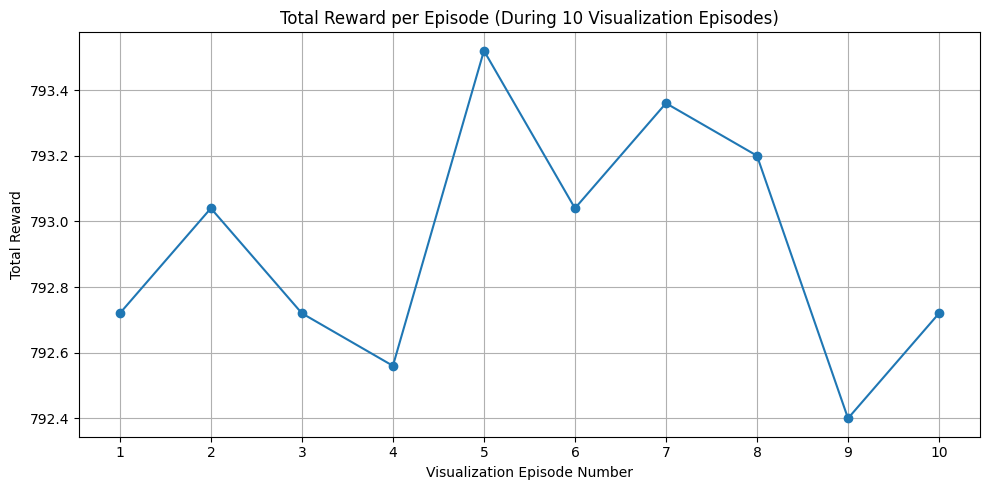


--- 6. Plotting Training Logs ---
Training log file not found at 'training_logs_ppo_scratch_resource_allocator_4types.csv'. Cannot plot training metrics.

--- Full Script Finished ---


In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.normal import Normal
import gymnasium as gym
from gymnasium import spaces
from shapely.geometry import Point, box
import contextily as ctx
import time
import os
from collections import deque
from tqdm.auto import tqdm
import matplotlib.animation as animation
from matplotlib.lines import Line2D
import copy
import random
from IPython import display 


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Setup")
if torch.cuda.is_available():
    print(f"Using device: {DEVICE} ({torch.cuda.get_device_name(0)})")
else:
    print(f"Using device: {DEVICE}")


#Data Preparation and Grid Generation
print("\n Data Preparation")

#Data Load
try:
    data = pd.read_csv("Received_Traffic_Incident_Calls_20250430.csv") 
    print(f"Loaded raw data: {data.shape[0]} rows.")
except FileNotFoundError:
    raise FileNotFoundError("ERROR: CSV file 'Received_Traffic_Incident_Calls_20250430.csv' not found.")

#Data Cleaning & Filtering
print("Cleaning and filtering data...")
# Police District Analysis ]
zone_counts = data['POLICE DISTRICT'].value_counts().reset_index()
zone_counts.columns = ['POLICE DISTRICT', 'Incident Count']
print("Incident Counts by Police District:")
print(zone_counts)

# Location Extraction and Filtering
data = data.dropna(subset=['LOCATION'])
data['Longitude'] = data['LOCATION'].str.extract(r'POINT \((-?\d+\.\d+)')[0].astype(float)
data['Latitude']  = data['LOCATION'].str.extract(r'POINT \(-?\d+\.\d+ (\d+\.\d+)\)')[0].astype(float)
data = data.dropna(subset=['Latitude', 'Longitude'])
# Apply geographical bounds 
data = data[
    (data['Latitude'] >= 42.84) & (data['Latitude'] <= 43.03) &
    (data['Longitude'] >= -78.91) & (data['Longitude'] <= -78.75)
].copy()
print(f"Data after location extraction and bounding: {data.shape[0]} rows.")

print("Creating grid zones...")
lat_bin_size = 0.005
lon_bin_size = 0.005
lat_min, lat_max = data['Latitude'].min(), data['Latitude'].max()
lon_min, lon_max = data['Longitude'].min(), data['Longitude'].max()
lat_edges = np.arange(lat_min, lat_max + lat_bin_size, lat_bin_size)
lon_edges = np.arange(lon_min, lon_max + lon_bin_size, lon_bin_size)


lat_edges = np.unique(lat_edges)
lon_edges = np.unique(lon_edges)


data['lat_bin'] = np.digitize(data['Latitude'], lat_edges) - 1
data['lon_bin'] = np.digitize(data['Longitude'], lon_edges) - 1

data = data[(data['lat_bin'] >= 0) & (data['lat_bin'] < len(lat_edges) - 1)]
data = data[(data['lon_bin'] >= 0) & (data['lon_bin'] < len(lon_edges) - 1)]

data['grid_id'] = data['lat_bin'].astype(str) + '_' + data['lon_bin'].astype(str)
print(f"Created {len(lat_edges)-1} latitude bins and {len(lon_edges)-1} longitude bins.")
print(f"Assigned grid IDs to {data.shape[0]} incidents.")

try:
    np.save('lat_edges.npy', lat_edges)
    np.save('lon_edges.npy', lon_edges)
    print("Saved lat/lon edges to .npy files.")
except Exception as e:
    print(f"Warning: Could not save lat/lon edges: {e}")

# Calculate Accident Probabilities per Grid
print("Calculating accident type probabilities per grid...")
if 'Accident Type' not in data.columns:
     print("Warning: 'Accident Type' column not found. Using placeholder types.")
     data['Accident Type'] = 'UNKNOWN'

accident_counts = data.groupby(['grid_id', 'Accident Type']).size().reset_index(name='count')
total_counts = data.groupby('grid_id').size().reset_index(name='total')
accident_probs_df = pd.merge(accident_counts, total_counts, on='grid_id')
accident_probs_df['probability'] = accident_probs_df['count'] / accident_probs_df['total']

# Pivot to create the matrix: grid_id vs Accident Type probability
# Fill missing combinations with 0 probability
accident_prob_matrix = accident_probs_df.pivot(
    index='grid_id', columns='Accident Type', values='probability'
).fillna(0)
print(f"Created accident probability matrix with shape: {accident_prob_matrix.shape}")

# Define Resource Needs and Calculate Need Probability
print("Defining resource needs and calculating need probabilities...")
RESOURCE_TYPES = ['police', 'ems', 'fire', 'dot']
NUM_RESOURCE_TYPES = len(RESOURCE_TYPES)

ACCIDENT_TYPE_TO_RESOURCE = {
    'PROPERTY DAMAGE': ['police', 'fire', 'dot'],
    'INJURY ACCIDENT': ['police', 'ems', 'fire', 'dot'],
    'SKYWAY INCIDENT': ['police', 'ems', 'fire', 'dot'],
    'HIT AND RUN': ['police', 'dot'],
    'UNKNOWN': ['police'],
    'NO DETAILS': ['police'],
    'VEHICLE FIRE': ['police', 'fire'],
    'DISABLED VEHICLE': ['police', 'dot'],
    'MINOR ACCIDENT - NO INJURY': ['police', 'dot'],
}

# Add any missing accident types from the matrix to the mapping
for acc_type in accident_prob_matrix.columns:
    if acc_type not in ACCIDENT_TYPE_TO_RESOURCE:
        print(f"  Mapping missing type '{acc_type}' to default ['police']")
        ACCIDENT_TYPE_TO_RESOURCE[acc_type] = ['police']

# Define grid IDs from the probability matrix index
grid_ids = accident_prob_matrix.index.tolist()
num_zones = len(grid_ids)

# Calculate Expected Resource Need Probability Per Grid
resource_need_prob = pd.DataFrame(0.0, index=grid_ids, columns=RESOURCE_TYPES)

for accident_type, resources_needed in ACCIDENT_TYPE_TO_RESOURCE.items():
    if accident_type in accident_prob_matrix.columns:
        for resource in resources_needed:
            if resource in resource_need_prob.columns:

                resource_need_prob[resource] = resource_need_prob[resource].add(
                    accident_prob_matrix[accident_type], fill_value=0
                )

# Normalize need probabilitie
# resource_need_prob = resource_need_prob.apply(lambda x: x / x.sum() if x.sum() > 0 else x, axis=1) # Normalize per grid
# resource_need_prob = resource_need_prob / resource_need_prob.sum().sum() # Normalize globally (less common)

print(f"Calculated Resource Need Probabilities ({NUM_RESOURCE_TYPES} types) for {num_zones} zones.")
print("Sample Need Probabilities:")
print(resource_need_prob.head())

# 2. Environment Definition
print("\n--- 2. Defining Environment ---")

# Environment Class (ResourceAllocationEnv
class ResourceAllocationEnv(gym.Env):
    metadata = {'render_modes': ['human'], 'render_fps': 4}

    def __init__(self, resource_need_prob_df, total_resources_dict, resource_types_list, max_resources_per_zone=8, movement_cost_factor=0.1):
        super().__init__()
        self.render_mode = None # Added for compatibility if render modes specified in metadata

        if not isinstance(resource_need_prob_df, pd.DataFrame) or not hasattr(resource_need_prob_df, 'index'):
             raise ValueError("resource_need_prob_df must be a pandas DataFrame with an index.")
        self.grid_ids = resource_need_prob_df.index.tolist()
        self.num_zones = len(self.grid_ids)
        self.resource_types = resource_types_list
        self.num_resource_types = len(self.resource_types)

        self.resource_need_prob = resource_need_prob_df.values

        try:
            self.total_resources = np.array([total_resources_dict[res_type] for res_type in self.resource_types], dtype=np.int32)
        except KeyError as e:
            raise KeyError(f"Resource type {e} found in resource_types_list but not in total_resources_dict keys.")

        self.max_resources_per_zone = max_resources_per_zone
        self.movement_cost_factor = movement_cost_factor

        # Defining Spaces
        obs_shape = (self.num_zones, self.num_resource_types * 2)
        obs_low = np.zeros(obs_shape, dtype=np.float32)
        obs_high = np.ones_like(obs_low)
        obs_high[:, self.num_resource_types:] = self.max_resources_per_zone
        self.observation_space = spaces.Box(
            low=obs_low.flatten(),
            high=obs_high.flatten(),
            shape=(self.num_zones * self.num_resource_types * 2,), 
            dtype=np.float32
        )

        # Action space: Target allocation for each resource in each zone
        self.action_space = spaces.Box(
            low=0,
            high=1,
            shape=(self.num_zones * self.num_resource_types,), 
            dtype=np.float32
        )

        # Internal state: Current allocation
        self.current_allocation = np.zeros((self.num_zones, self.num_resource_types), dtype=np.int32)

        print(f"Environment Initialized")
        print(f"  Num Zones: {self.num_zones}")
        print(f"  Resource Types: {self.resource_types}")
        print(f"  Num Resource Types: {self.num_resource_types}")
        print(f"  Observation Shape: {self.observation_space.shape}")
        print(f"  Action Shape: {self.action_space.shape}")
        print(f"  Total Resources: {dict(zip(self.resource_types, self.total_resources))}")
        print(f"  Max Per Zone: {self.max_resources_per_zone}")
        print(f"-----------------------------")


    def _initial_allocation(self):
        """Distribute total resources somewhat randomly or proportionally at the start."""
        self.current_allocation.fill(0)
        total_need_per_zone = self.resource_need_prob.sum(axis=1)

        need_sum = total_need_per_zone.sum()
        if need_sum > 1e-6:
            zone_alloc_prob = total_need_per_zone / need_sum
        else: 
            zone_alloc_prob = np.ones(self.num_zones) / self.num_zones

        for r_idx in range(self.num_resource_types):
            total_r = self.total_resources[r_idx]

            proportional_alloc = np.minimum(np.floor(zone_alloc_prob * total_r), self.max_resources_per_zone).astype(np.int32)
            self.current_allocation[:, r_idx] = proportional_alloc
            allocated_r = proportional_alloc.sum()


            remaining_r = total_r - allocated_r
            possible_zones = np.where(self.current_allocation[:, r_idx] < self.max_resources_per_zone)[0]
            while remaining_r > 0 and len(possible_zones) > 0:
                zone_idx = np.random.choice(possible_zones)
                self.current_allocation[zone_idx, r_idx] += 1
                remaining_r -= 1
                if self.current_allocation[zone_idx, r_idx] >= self.max_resources_per_zone:
                   possible_zones = np.where(self.current_allocation[:, r_idx] < self.max_resources_per_zone)[0]
\
            final_sum = self.current_allocation[:, r_idx].sum()
            excess = final_sum - total_r
            if excess > 0:
                allocated_indices = np.where(self.current_allocation[:, r_idx] > 0)[0]
                while excess > 0 and len(allocated_indices) > 0:

                    zone_idx = np.random.choice(allocated_indices)
                    self.current_allocation[zone_idx, r_idx] -= 1
                    excess -= 1
                    if self.current_allocation[zone_idx, r_idx] == 0:
                        allocated_indices = np.where(self.current_allocation[:, r_idx] > 0)[0]


        allocated_sums = self.current_allocation.sum(axis=0)
        if not np.all(allocated_sums <= self.total_resources):
             print(f"WARNING: Initial allocation sum {allocated_sums} exceeds total available {self.total_resources}!")

             for r_idx in range(self.num_resource_types):
                 if allocated_sums[r_idx] > self.total_resources[r_idx]:
                     excess = allocated_sums[r_idx] - self.total_resources[r_idx]
                     while excess > 0:
                         max_alloc_idx = np.argmax(self.current_allocation[:, r_idx])
                         if self.current_allocation[max_alloc_idx, r_idx] > 0:
                             self.current_allocation[max_alloc_idx, r_idx] -= 1
                             excess -= 1
                         else:
                             break 
        # print("Initial Allocation Sum After Correction:", dict(zip(self.resource_types, self.current_allocation.sum(axis=0))))


    def _get_obs(self):
        """Construct the observation from needs and current allocation."""
        obs = np.concatenate(
            (self.resource_need_prob.astype(np.float32),
             self.current_allocation.astype(np.float32)),
            axis=1
        )
        return obs.flatten()

    def _get_info(self):
        """Return auxiliary information."""
        return {
            "total_allocated": dict(zip(self.resource_types, self.current_allocation.sum(axis=0))),
            "total_available": dict(zip(self.resource_types, self.total_resources))
        }

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._initial_allocation()
        observation = self._get_obs()
        info = self._get_info()
        return observation, info

    def step(self, action):
        action = np.asarray(action, dtype=np.float32)

        # Process Action
        target_allocation_normalized = np.clip(action, 0.0, 1.0).reshape((self.num_zones, self.num_resource_types))
        target_allocation = np.round(target_allocation_normalized * self.max_resources_per_zone).astype(np.int32)
        target_allocation = np.minimum(target_allocation, self.max_resources_per_zone)

        previous_allocation = self.current_allocation.copy()
        new_allocation = np.zeros_like(self.current_allocation)
        total_over_allocated_penalty = 0.0

        for r_idx in range(self.num_resource_types):
            total_r = self.total_resources[r_idx]
            target_r_vector = target_allocation[:, r_idx]

            agent_requested_sum = target_r_vector.sum()
            if agent_requested_sum > total_r:
                 over_alloc_penalty = (agent_requested_sum - total_r) * 0.05
                 total_over_allocated_penalty += over_alloc_penalty

            zone_indices_sorted = np.argsort(-target_r_vector) # Descending order of target
            allocated_count = 0
            for zone_idx in zone_indices_sorted:
                desired_count = target_r_vector[zone_idx]
                assign_count = min(desired_count, total_r - allocated_count)
                if assign_count > 0:
                    new_allocation[zone_idx, r_idx] = assign_count
                    allocated_count += assign_count
                if allocated_count >= total_r:
                    break

        self.current_allocation = new_allocation

        movement_cost = np.sum(np.abs(self.current_allocation - previous_allocation))
        match_reward = np.sum(self.resource_need_prob * self.current_allocation)
        reward = match_reward - (movement_cost * self.movement_cost_factor) - total_over_allocated_penalty

        terminated = False
        truncated = False

        observation = self._get_obs()
        info = self._get_info()
        info["movement_cost"] = movement_cost
        info["match_reward"] = match_reward
        info["over_alloc_penalty"] = total_over_allocated_penalty

        return observation, reward, terminated, truncated, info

    def render(self):
        if self.render_mode == 'human':
            print("-" * 30)
            print(f"Step Render:")
            current_alloc_sum = self.current_allocation.sum(axis=0)
            print(f" Current Allocation Sum: {dict(zip(self.resource_types, current_alloc_sum))}")
            # Create DataFrame for display if grid_ids are available
            if hasattr(self, 'grid_ids') and len(self.grid_ids) == self.num_zones:
                 alloc_df = pd.DataFrame(self.current_allocation, index=self.grid_ids, columns=self.resource_types)
                 print(" Allocation (Head):")
                 print(alloc_df.head())
            else:
                 print(" Raw Allocation Array (Head):")
                 print(self.current_allocation[:5, :])
            print("-" * 30)

    def close(self):
        pass

print("Environment class defined.")

# FROM-SCRATCH PPO Components (Adapted for Continuous Actions)
print("3. Defining From-Scratch PPO Components")

def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    """Initializes weights orthogonally and biases to a constant."""
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

# Actor-Critic Network 
class ActorCriticPPOContinuous(nn.Module):
    def __init__(self, obs_shape, action_dim):
        super().__init__()
        input_dim = np.prod(obs_shape)
        self.action_dim = action_dim

        # Shared network layers
        shared_net = nn.Sequential(
            layer_init(nn.Linear(input_dim, 256)),
            nn.Tanh(),
            layer_init(nn.Linear(256, 128)),
            nn.Tanh()
        )

        # Critic head (estimates state value)
        self.critic = nn.Sequential(
            shared_net,
            layer_init(nn.Linear(128, 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, 1), std=1.0)
        )

        # Actor head (outputs mean of Gaussian distribution)
        self.actor_mean = nn.Sequential(
            shared_net,
            layer_init(nn.Linear(128, 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, action_dim), std=0.01) 
        )

        # Log standard deviation (learned parameter, one per action dimension)
        # Initialized near zero std near 1.0 initially
        self.actor_log_std = nn.Parameter(torch.zeros(1, action_dim))

    def get_value(self, x):
        """Returns the estimated value of the state."""
        if isinstance(x, np.ndarray):
            x = torch.tensor(x, dtype=torch.float32, device=self.critic[-1].weight.device) # Use critic's device
        if x.ndim == 1: x = x.unsqueeze(0)
        x = x.view(x.size(0), -1) 
        return self.critic(x)

    def get_action_value_logprob_entropy(self, x, provided_action=None):
        """
        Returns action(s), value, log prob, and entropy for continuous actions.
        """
        if isinstance(x, np.ndarray):
            x = torch.tensor(x, dtype=torch.float32, device=self.actor_mean[-1].weight.device) # Use actor's device
        if x.ndim == 1: x = x.unsqueeze(0)
        x = x.view(x.size(0), -1) 

        action_mean = self.actor_mean(x)
        value = self.critic(x)

        # Expand log_std to match batch size
        action_log_std = self.actor_log_std.expand_as(action_mean)
        action_std = torch.exp(action_log_std)

        # Create the Normal distribution
        dist = Normal(action_mean, action_std)

        if provided_action is None:
            action = dist.sample()
        else:
            # Ensure provided action is a tensor on the correct device
            if isinstance(provided_action, np.ndarray):
                 provided_action = torch.tensor(provided_action, dtype=torch.float32, device=action_mean.device)
            action = provided_action

        log_prob = dist.log_prob(action).sum(1) # Sum log probs across action dimensions
        entropy = dist.entropy().sum(1)         # Sum entropy across action dimensions

        # Action is returned potentially unbounded; env step clips/scales it
        return action, value, log_prob, entropy

    def get_action(self, x, deterministic=False):
        """Gets an action for inference."""
        if isinstance(x, np.ndarray):
            x = torch.tensor(x, dtype=torch.float32, device=self.actor_mean[-1].weight.device)
        if x.ndim == 1: x = x.unsqueeze(0)
        x = x.view(x.size(0), -1) # Flatten input

        action_mean = self.actor_mean(x)

        if deterministic:
            action = action_mean # Use the mean for deterministic action
        else:
            action_log_std = self.actor_log_std.expand_as(action_mean)
            action_std = torch.exp(action_log_std)
            dist = Normal(action_mean, action_std)
            action = dist.sample()

        # Clip action to valid range (0 to 1 for this env's normalized space)

        action = torch.clamp(action, 0.0, 1.0)

        return action, action_mean 


class RolloutBufferContinuous:
    def __init__(self, num_steps, obs_shape, action_shape, device, gamma, gae_lambda):
        self.num_steps = num_steps
        self.obs_shape = obs_shape
        self.action_shape = action_shape 
        self.action_dim = np.prod(action_shape)
        self.device = device
        self.gamma = gamma
        self.gae_lambda = gae_lambda

        self.observations = np.zeros((num_steps,) + obs_shape, dtype=np.float32)
        self.actions = np.zeros((num_steps, self.action_dim), dtype=np.float32) 
        self.log_probs = np.zeros(num_steps, dtype=np.float32)
        self.rewards = np.zeros(num_steps, dtype=np.float32)
        self.dones = np.zeros(num_steps, dtype=np.float32)
        self.values = np.zeros(num_steps, dtype=np.float32)
        self.advantages = np.zeros(num_steps, dtype=np.float32)
        self.returns = np.zeros(num_steps, dtype=np.float32)

        self.ptr = 0
        self.buffer_filled = False

    def add(self, obs, action, reward, done, log_prob, value):
        """Adds a single transition to the buffer."""
        if self.ptr >= self.num_steps:
            print(f"Warning: RolloutBuffer pointer ({self.ptr}) exceeded num_steps ({self.num_steps}). Resetting.")
            self.ptr = 0 
        self.observations[self.ptr] = obs.astype(np.float32)

        action_array = np.array(action).flatten()
        if action_array.shape == (self.action_dim,):
             self.actions[self.ptr] = action_array.astype(np.float32)
        else:
             print(f"Error: RolloutBuffer action shape mismatch. Expected ({self.action_dim},), got {action_array.shape}. Skipping add.")
             return 
        self.rewards[self.ptr] = float(reward)
        self.dones[self.ptr] = float(done)
        self.log_probs[self.ptr] = float(log_prob)

        self.values[self.ptr] = float(value.item() if isinstance(value, torch.Tensor) else value)

        self.ptr += 1
        if self.ptr == self.num_steps:
            self.ptr = 0 
            self.buffer_filled = True

    def compute_returns_and_advantages(self, last_value, last_done):
        """Computes GAE and returns."""
        last_value_f = float(last_value.item() if isinstance(last_value, torch.Tensor) else last_value)
        last_done_f = float(last_done)
        last_gae_lam = 0
        num_samples = self.num_steps

        if num_samples == 0:
            print("Warning: compute_returns_and_advantages called with zero samples.")
            return

        for t in reversed(range(num_samples)):
            if t == self.num_steps - 1:
                next_non_terminal = 1.0 - last_done_f
                next_values = last_value_f
            else:
                next_non_terminal = 1.0 - self.dones[t + 1]
                next_values = self.values[t + 1]

            delta = self.rewards[t] + self.gamma * next_values * next_non_terminal - self.values[t]
            last_gae_lam = delta + self.gamma * self.gae_lambda * next_non_terminal * last_gae_lam
            self.advantages[t] = last_gae_lam

        self.returns[:num_samples] = self.advantages[:num_samples] + self.values[:num_samples]

    def get(self, batch_size):
        """Returns a generator that yields batches of experiences."""
        num_samples = self.num_steps
        if num_samples == 0:
            print("Warning: RolloutBuffer.get() called with zero samples.")
            return

        indices = np.random.permutation(num_samples)

        obs_valid = self.observations[:num_samples]
        actions_valid = self.actions[:num_samples] # float32 actions
        log_probs_valid = self.log_probs[:num_samples]
        advantages_valid = self.advantages[:num_samples]
        returns_valid = self.returns[:num_samples]
        values_valid = self.values[:num_samples]

        # Flatten observations
        obs_flat = obs_valid.reshape(num_samples, -1)

        # Normalize advantages
        adv_mean, adv_std = np.mean(advantages_valid), np.std(advantages_valid)
        advantages_norm = (advantages_valid - adv_mean) / (adv_std + 1e-8)

        for start in range(0, num_samples, batch_size):
            end = min(start + batch_size, num_samples)
            batch_indices = indices[start:end]
            if len(batch_indices) == 0: continue

            yield (
                torch.tensor(obs_flat[batch_indices], dtype=torch.float32).to(self.device),
                torch.tensor(actions_valid[batch_indices], dtype=torch.float32).to(self.device), # Send float actions
                torch.tensor(log_probs_valid[batch_indices], dtype=torch.float32).to(self.device),
                torch.tensor(advantages_norm[batch_indices], dtype=torch.float32).to(self.device),
                torch.tensor(returns_valid[batch_indices], dtype=torch.float32).to(self.device),
                torch.tensor(values_valid[batch_indices], dtype=torch.float32).to(self.device)
            )

# PPO Agent Class
class PPOAgentWithLoggingContinuous:
    def __init__(self, env, learning_rate=3e-4, n_steps=2048, batch_size=64,
                 n_epochs=10, gamma=0.99, gae_lambda=0.95, clip_epsilon=0.2,
                 ent_coef=0.01, vf_coef=0.5, max_grad_norm=0.5, device=DEVICE):

        self.env = env
        self.obs_shape = env.observation_space.shape
        # Changed: Get action shape for continuous
        self.action_shape = env.action_space.shape
        self.action_dim = np.prod(self.action_shape)

        self.lr = learning_rate
        self.n_steps = n_steps
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_epsilon = clip_epsilon
        self.ent_coef = ent_coef
        self.vf_coef = vf_coef
        self.max_grad_norm = max_grad_norm
        self.device = device

        if hasattr(env, 'resource_types'):
            self.resource_types = env.resource_types
        else: # Fallback
            self.resource_types = [f"Res_{i}" for i in range(env.num_resource_types)]

        # Use Continuous ActorCritic and Buffer
        self.actor_critic = ActorCriticPPOContinuous(self.obs_shape, self.action_dim).to(device)
        self.optimizer = optim.Adam(self.actor_critic.parameters(), lr=self.lr, eps=1e-5)
        self.buffer = RolloutBufferContinuous(
            self.n_steps, self.obs_shape, self.action_shape,
            self.device, self.gamma, self.gae_lambda
        )

        # Training state and logging
        self.global_step = 0
        self.start_time = time.time()
        self.episode_rewards_raw = deque(maxlen=100)
        self.log_data = { # Same log structure
            "step": [], "avg_reward_100": [], "policy_loss": [],
            "value_loss": [], "entropy_loss": [], "total_allocated": [],
            "total_remaining": [],
            # Add std deviation if needed: "actor_std": []
        }
        for res_type in self.resource_types:
            self.log_data[f"remaining_{res_type}"] = []
        self.last_detailed_log_step = 0

    def train(self, total_timesteps, log_every_steps=1000, detailed_log_every_steps=5000):
        """Trains the PPO agent."""
        print(f"Starting PPO training for {total_timesteps} timesteps (Continuous Actions)...")
        print(f"  n_steps={self.n_steps}, batch_size={self.batch_size}, n_epochs={self.n_epochs}")
        print(f"  ent_coef={self.ent_coef}, vf_coef={self.vf_coef}, clip_epsilon={self.clip_epsilon}")
        print(f"  Device: {self.device}")

        # Use the single environment instance
        obs, info = self.env.reset()
        current_episode_reward = 0
        last_step_done = True
        pbar = tqdm(total=total_timesteps, desc="Training Timesteps", unit="step")

        update_policy_losses = deque(maxlen=10)
        update_value_losses = deque(maxlen=10)
        update_entropy_losses = deque(maxlen=10)
        last_info_in_rollout = info

        while self.global_step < total_timesteps:

            self.actor_critic.eval()

            for step in range(self.n_steps):
                self.global_step += 1
                pbar.update(1)
                if self.global_step > total_timesteps: break

                obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(self.device)
                with torch.no_grad():
                    # Get continuous action, value, log_prob, entropy
                    action, value, log_prob, _ = self.actor_critic.get_action_value_logprob_entropy(obs_tensor)

                # Convert action tensor to numpy array
                action_np = action.cpu().numpy().flatten() # Flatten action for env step
                log_prob_np = log_prob.cpu().numpy()
                value_np = value.cpu().numpy().item()

                # Step environment with the continuous action
                next_obs, reward_original, terminated, truncated, info = self.env.step(action_np)
                last_info_in_rollout = info
                # reward_clipped = np.clip(reward_original, self.reward_clip_min, self.reward_clip_max)
                reward_clipped = reward_original # Using original reward for now
                done = terminated or truncated
                current_episode_reward += reward_original

                self.buffer.add(obs, action_np, reward_clipped, done, log_prob_np, value_np)

                obs = next_obs
                last_step_done = done


                if self.global_step - self.last_detailed_log_step >= detailed_log_every_steps:
                    avg_reward_100_orig = np.mean(self.episode_rewards_raw) if self.episode_rewards_raw else np.nan
                    avg_ploss = np.mean(update_policy_losses) if update_policy_losses else np.nan
                    avg_vloss = np.mean(update_value_losses) if update_value_losses else np.nan
                    avg_eloss = np.mean(update_entropy_losses) if update_entropy_losses else np.nan
                    remaining_res_dict = info.get('remaining_resources', {})
                    total_allocated = info.get('total_allocated', 'N/A')
                    #current std dev
                    current_std = torch.exp(self.actor_critic.actor_log_std).mean().item()

                    print(f"\n--- Log @ Timestep {self.global_step}/{total_timesteps} ---")
                    print(f"  Avg Reward (Last {len(self.episode_rewards_raw)} Eps): {avg_reward_100_orig:.3f}")
                    print(f"  Avg Policy Loss: {avg_ploss:.4f}, Avg Value Loss: {avg_vloss:.4f}, Avg Entropy: {-avg_eloss:.4f}")
                    print(f"  Actor Mean Std Dev: {current_std:.4f}")
                    print(f"  Current Remaining Resources: {remaining_res_dict}, Total Allocated: {total_allocated}")
                    print(f"--------------------------------------------------")
                    self.last_detailed_log_step = self.global_step


                if done:
                    self.episode_rewards_raw.append(current_episode_reward)
                    current_episode_reward = 0
                    obs, info = self.env.reset()
                    last_info_in_rollout = info

            if self.global_step > total_timesteps: break

            #Compute Advantages and Returns
            with torch.no_grad():
                last_obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(self.device)
                last_value = self.actor_critic.get_value(last_obs_tensor)
            self.buffer.compute_returns_and_advantages(last_value, last_step_done)

            #PPO Update
            self.actor_critic.train()
            cycle_policy_losses, cycle_value_losses, cycle_entropy_losses = [], [], []

            for epoch in range(self.n_epochs):
                for batch_data in self.buffer.get(self.batch_size):
                    b_obs, b_actions, b_old_log_probs, b_advantages, b_returns, b_old_values = batch_data

                    #getting new values, log_probs, and entropy for the batch actions
                    _, new_values, new_log_probs, entropy = \
                        self.actor_critic.get_action_value_logprob_entropy(b_obs, provided_action=b_actions)

                    new_values = new_values.squeeze(-1)

                    #Policy Loss
                    log_ratio = new_log_probs - b_old_log_probs
                    ratio = torch.exp(log_ratio)
                    surr1 = ratio * b_advantages
                    surr2 = torch.clamp(ratio, 1 - self.clip_epsilon, 1 + self.clip_epsilon) * b_advantages
                    policy_loss = -torch.min(surr1, surr2).mean()

                    #Value Loss (MSE)
                    value_loss = 0.5 * ((new_values - b_returns) ** 2).mean()

                    #Entropy Loss
                    entropy_loss = -entropy.mean()

                    #Total Loss
                    loss = policy_loss + self.ent_coef * entropy_loss + self.vf_coef * value_loss

                    #Optimization step
                    self.optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.actor_critic.parameters(), self.max_grad_norm)
                    self.optimizer.step()

                    cycle_policy_losses.append(policy_loss.item())
                    cycle_value_losses.append(value_loss.item())
                    cycle_entropy_losses.append(entropy_loss.item())

            update_policy_losses.append(np.mean(cycle_policy_losses))
            update_value_losses.append(np.mean(cycle_value_losses))
            update_entropy_losses.append(np.mean(cycle_entropy_losses))

            if self.global_step % log_every_steps == 0 or self.global_step >= total_timesteps:
                avg_reward_100_orig = np.mean(self.episode_rewards_raw) if self.episode_rewards_raw else np.nan
                avg_ploss = update_policy_losses[-1] if update_policy_losses else np.nan
                avg_vloss = update_value_losses[-1] if update_value_losses else np.nan
                avg_eloss = update_entropy_losses[-1] if update_entropy_losses else np.nan
                elapsed_time = time.time() - self.start_time
                steps_per_sec = self.global_step / elapsed_time if elapsed_time > 0 else 0
                current_std = torch.exp(self.actor_critic.actor_log_std).mean().item()

                pbar.set_postfix({
                    "Avg Rew": f"{avg_reward_100_orig:.2f}", "P Loss": f"{avg_ploss:.3f}",
                    "V Loss": f"{avg_vloss:.3f}", "Entropy": f"{-avg_eloss:.3f}",
                    "Std": f"{current_std:.3f}", "SPS": f"{steps_per_sec:.0f}"
                })

                self.log_data["step"].append(self.global_step)
                self.log_data["avg_reward_100"].append(avg_reward_100_orig)
                self.log_data["policy_loss"].append(avg_ploss)
                self.log_data["value_loss"].append(avg_vloss)
                self.log_data["entropy_loss"].append(-avg_eloss)
                self.log_data["total_allocated"].append(last_info_in_rollout.get('total_allocated', {}).get('sum', np.nan)) 
                self.log_data["total_remaining"].append(last_info_in_rollout.get('total_available', {}).get('sum', np.nan)) 
                current_remaining = last_info_in_rollout.get('total_available', {}) 
                for res_type in self.resource_types:
                     self.log_data[f"remaining_{res_type}"].append(current_remaining.get(res_type, np.nan))

        pbar.close()
        print("Training finished.")
        self.save_logs()

    def save(self, path="ppo_scratch_resource_allocator_4types.pth"):
        """Saves the actor-critic network state dictionary."""
        try:
            dir_name = os.path.dirname(path)
            if dir_name: os.makedirs(dir_name, exist_ok=True)
            torch.save(self.actor_critic.state_dict(), path)
            print(f"PPO ActorCritic Network saved to {path}")
        except Exception as e:
            print(f"Error saving PPO model to {path}: {e}")

    def load(self, path="ppo_scratch_resource_allocator_4types.pth"):
        """Loads the actor-critic network state dictionary."""
        if os.path.exists(path):
            try:
                self.actor_critic.load_state_dict(torch.load(path, map_location=self.device))
                self.actor_critic.to(self.device)
                print(f"PPO ActorCritic Network loaded from {path}")
            except Exception as e:
                print(f"Error loading PPO model from {path}: {e}")
        else:
            print(f"Warning: PPO Model file not found at {path}. Starting with untrained model.")

    def save_logs(self, log_path="training_logs_ppo_continuous.csv"):
        """Saves the collected training logs to a CSV file."""
        print(f"\nSaving training logs to {log_path}...")
        if not self.log_data or not self.log_data["step"]:
            print("Warning: No log data collected. Skipping log saving.")
            return
        try:
            lengths = {key: len(value) for key, value in self.log_data.items()}
            if len(set(lengths.values())) > 1:
                min_len = min(lengths.values()) if lengths else 0
                print(f"Warning: Log data columns inconsistent lengths! Truncating to {min_len}.")
                final_log_data = {key: value[:min_len] for key, value in self.log_data.items()}
            else:
                final_log_data = self.log_data
                min_len = len(self.log_data["step"])

            if min_len > 0:
                log_df = pd.DataFrame(final_log_data)
                log_df.to_csv(log_path, index=False)
                print(f"Logs saved successfully to {log_path} ({min_len} data points).")
            else:
                print("Warning: No log data points recorded. Skipping log saving.")
        except Exception as e:
            print(f"CRITICAL Error saving logs: {e}")

print("From-scratch PPO components defined.")


print("\nTraining Setup (Custom PPO)")


TOTAL_RESOURCES = {'police': 50, 'ems': 15, 'fire': 20, 'dot': 10}
MAX_RESOURCES_PER_ZONE = 8
env_kwargs = dict(
    resource_need_prob_df=resource_need_prob, 
    total_resources_dict=TOTAL_RESOURCES,
    resource_types_list=RESOURCE_TYPES,
    max_resources_per_zone=MAX_RESOURCES_PER_ZONE,
    movement_cost_factor=0.08 
)

#single training instance
try:
    train_env = ResourceAllocationEnv(**env_kwargs)
    print("Created single training environment instance.")
except Exception as e:
    print(f"FATAL: Could not create training environment: {e}")
    exit()

#PPO Hyperparameters
ppo_config = {
    "learning_rate": 3e-4,      
    "n_steps": 2048,            
    "batch_size": 64,           
    "n_epochs": 10,             
    "gae_lambda": 0.95,         
    "clip_epsilon": 0.2,        
    "ent_coef": 0.01,          
    "vf_coef": 0.5,             
    "max_grad_norm": 0.5,       
    "device": DEVICE
}
print(f"PPO Config: {ppo_config}")

#training parameter
model_name = "ppo_scratch_resource_allocator_4types" 
model_save_path = f"{model_name}.pth" 
log_save_path = f"training_logs_{model_name}.csv"
total_timesteps = 300_000 
log_every_steps = 4096 
detailed_log_every_steps = 20000 

#train custom agent
agent = PPOAgentWithLoggingContinuous(train_env, **ppo_config)

print(f"\nStarting training with custom PPO for {total_timesteps} timesteps...")
agent.train(
    total_timesteps=total_timesteps,
    log_every_steps=log_every_steps,
    detailed_log_every_steps=detailed_log_every_steps
)
print("Training finished.")

agent.save(model_save_path)
train_env.close()


#Evaluation
print("\nEvaluating and Visualizing Trained Custom PPO Agent")

N_EPISODES_TO_VISUALIZE = 10
N_STEPS_PER_EPISODE = 24
PAUSE_DURATION = 0.3
AGENT_LOAD_PATH = model_save_path

print("Loading prerequisites for evaluation...")

#edges load
try:
    lat_edges = np.load('lat_edges.npy')
    lon_edges = np.load('lon_edges.npy')
    print("Loaded lat/lon edges from file.")
except FileNotFoundError:
    print("ERROR: lat_edges.npy or lon_edges.npy not found. Cannot create grid for visualization.")
    exit()

#evaluation env
try:
    eval_env = ResourceAllocationEnv(**env_kwargs)
    print("Created evaluation environment instance.")
except Exception as e:
    print(f"ERROR: Could not create evaluation environment instance. Details: {e}")
    exit()

#trained model load
actor_critic_eval = ActorCriticPPOContinuous(
    eval_env.observation_space.shape,
    eval_env.action_space.shape[0] # action_dim
).to(DEVICE)

#state dictionary load
if os.path.exists(AGENT_LOAD_PATH):
    try:
        actor_critic_eval.load_state_dict(torch.load(AGENT_LOAD_PATH, map_location=DEVICE))
        actor_critic_eval.eval() # Set to evaluation mode
        print(f"Successfully loaded trained network weights from {AGENT_LOAD_PATH}")
    except Exception as e:
        print(f"Error loading model weights from {AGENT_LOAD_PATH}: {e}. Exiting.")
        exit()
else:
    print(f"Error: Trained agent file not found at {AGENT_LOAD_PATH}. Cannot evaluate.")
    exit()


#Plotting with Geo Dataframe
print("Creating Grid GeoDataFrame for visualization...")
grid_geometries = []
grid_ids_list = []
env_grid_ids = eval_env.grid_ids #grid_id extraction

for grid_id in env_grid_ids:
    try:
        lat_bin_idx_str, lon_bin_idx_str = grid_id.split('_')
        lat_bin_idx, lon_bin_idx = int(lat_bin_idx_str), int(lon_bin_idx_str)
        #checking bounds using loaded edges
        if not (0 <= lat_bin_idx < len(lat_edges) - 1 and 0 <= lon_bin_idx < len(lon_edges) - 1):
            print(f"Warning: Grid ID '{grid_id}' indices out of bounds of loaded edges. Skipping.")
            continue
        lon_min, lon_max = lon_edges[lon_bin_idx], lon_edges[lon_bin_idx + 1]
        lat_min, lat_max = lat_edges[lat_bin_idx], lat_edges[lat_bin_idx + 1]
        grid_geometries.append(box(lon_min, lat_min, lon_max, lat_max))
        grid_ids_list.append(grid_id)
    except (ValueError, IndexError) as e:
        print(f"Warning: Could not process grid_id '{grid_id}' for geometry. Skipping. Error: {e}")
        continue

if not grid_ids_list:
     print("ERROR: No valid grid geometries could be created. Cannot visualize.")
     exit()

grid_gdf = gpd.GeoDataFrame({'grid_id': grid_ids_list},
                            geometry=grid_geometries, crs="EPSG:4326").to_crs(epsg=3857)
print(f"Created GeoDataFrame with {len(grid_gdf)} grid zones for plotting.")


#Visualization
all_episode_rewards_vis = []
fig_vis, ax_vis = plt.subplots(figsize=(15, 15))

for episode in range(N_EPISODES_TO_VISUALIZE):
    print(f"\n--- Starting Visualization Episode {episode + 1}/{N_EPISODES_TO_VISUALIZE} ---")
    obs, info = eval_env.reset()
    episode_reward = 0

    for step in range(N_STEPS_PER_EPISODE):
        #deterministic action
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            #mean action
            action_tensor, _ = actor_critic_eval.get_action(obs_tensor, deterministic=True)
        action = action_tensor.cpu().numpy().flatten() # Get numpy array

        #env step
        obs, reward, terminated, truncated, info = eval_env.step(action)
        episode_reward += reward

        #allocation sum
        if step % 10 == 0:
             current_alloc_sum = eval_env.current_allocation.sum(axis=0)
             print(f"  Step {step+1} Alloc Sum: {dict(zip(RESOURCE_TYPES, current_alloc_sum))}")

        #preparing data for plot
        current_allocation_np = eval_env.current_allocation
        if len(env_grid_ids) == current_allocation_np.shape[0]:
             alloc_df = pd.DataFrame(current_allocation_np, index=env_grid_ids,
                                     columns=[f"{res}_alloc" for res in RESOURCE_TYPES]).reset_index().rename(columns={'index': 'grid_id'})
             plot_data_gdf = grid_gdf.merge(alloc_df, on='grid_id', how='left').fillna(0)
        else:
             print(f"Warning: Mismatch between env grid IDs ({len(env_grid_ids)}) and allocation shape ({current_allocation_np.shape[0]}). Skipping allocation merge.")
             plot_data_gdf = grid_gdf.copy() # Plot grid only


        #plot
        ax_vis.clear()
        plot_data_gdf.plot(ax=ax_vis, facecolor='none', edgecolor='grey', linewidth=0.5, alpha=0.7)
        for idx, row in plot_data_gdf.iterrows():
            #column check
            p_alloc = int(row.get(f'police_alloc', 0))
            e_alloc = int(row.get(f'ems_alloc', 0))
            f_alloc = int(row.get(f'fire_alloc', 0))
            d_alloc = int(row.get(f'dot_alloc', 0))
            if p_alloc + e_alloc + f_alloc + d_alloc > 0:
                alloc_text = f"P:{p_alloc} E:{e_alloc}\nF:{f_alloc} D:{d_alloc}"
                try:
                    centroid = row.geometry.centroid
                    ax_vis.text(centroid.x, centroid.y, alloc_text, ha='center', va='center', fontsize=6, color='black',
                            bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6, ec='none'))
                except AttributeError: # Handle case where geometry might be invalid
                    print(f"Warning: Could not get centroid for geometry at index {idx}. Skipping text.")


        try:
            ctx.add_basemap(ax_vis, source=ctx.providers.CartoDB.Positron)
        except Exception as e_ctx:
            print(f"Warning: Could not add basemap. {e_ctx}")
        ax_vis.set_title(f"Evaluation Episode {episode + 1}, Step {step + 1}/{N_STEPS_PER_EPISODE}\n"
                         f"Current Step Reward: {reward:.2f} | Episode Total Reward: {episode_reward:.2f}", fontsize=10)
        ax_vis.axis('off')

        #Update Dislay
        display.display(fig_vis)
        display.clear_output(wait=True)
        time.sleep(PAUSE_DURATION)

        if terminated or truncated:
            print(f"Episode {episode + 1} finished early at step {step + 1}.")
            break

    print(f"Visualization Episode {episode + 1} Finished. Final Total Reward: {episode_reward:.2f}")
    all_episode_rewards_vis.append(episode_reward)
    time.sleep(0.5)

plt.close(fig_vis)
print("\nMap Visualization finished.")
eval_env.close()

#Plotting Episode Rewards
if all_episode_rewards_vis:
    plt.figure(figsize=(10, 5))
    episode_numbers = range(1, len(all_episode_rewards_vis) + 1)
    plt.plot(episode_numbers, all_episode_rewards_vis, marker='o', linestyle='-')
    plt.title(f'Total Reward per Episode (During {len(all_episode_rewards_vis)} Visualization Episodes)')
    plt.xlabel('Visualization Episode Number')
    plt.ylabel('Total Reward')
    plt.xticks(episode_numbers)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No episode rewards recorded during evaluation visualization.")


#training logs plotting
print("\nPlotting Training Logs")
log_file_path = log_save_path #custom reward path

if not os.path.exists(log_file_path):
    print(f"Training log file not found at '{log_file_path}'. Cannot plot training metrics.")
else:
    print(f"Loading training logs from: {log_file_path}")
    try:
        log_df = pd.read_csv(log_file_path)
        print(f"Loaded {len(log_df)} log entries.")

        if not log_df.empty:
            steps = log_df['step']
            smooth_window = max(1, len(log_df) // 20) # Adjust smoothing window size

            fig_log, axs_log = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
            fig_log.suptitle('Custom PPO Training Metrics', fontsize=16)

            #average reward plotting
            if 'avg_reward_100' in log_df.columns:
                axs_log[0].plot(steps, log_df['avg_reward_100'].rolling(window=smooth_window, min_periods=1).mean(), label=f'Avg Reward (Smoothed {smooth_window})')
                axs_log[0].set_ylabel('Avg Reward (Last 100 Eps)')
                axs_log[0].set_title('Average Episode Reward')
                axs_log[0].grid(True)
                axs_log[0].legend()
            else:
                 axs_log[0].set_title('Average Episode Reward (Data Unavailable)')

            # Plot Losses
            if 'policy_loss' in log_df.columns and 'value_loss' in log_df.columns:
                axs_log[1].plot(steps, log_df['policy_loss'].rolling(window=smooth_window, min_periods=1).mean(), label=f'Policy Loss (Smoothed {smooth_window})', alpha=0.8)
                axs_log[1].plot(steps, log_df['value_loss'].rolling(window=smooth_window, min_periods=1).mean(), label=f'Value Loss (Smoothed {smooth_window})', alpha=0.8)
                axs_log[1].set_ylabel('Loss')
                axs_log[1].set_title('Policy and Value Losses')
                axs_log[1].grid(True)
                axs_log[1].legend()
            else:
                 axs_log[1].set_title('Losses (Data Unavailable)')

            #plot for entropy
            if 'entropy_loss' in log_df.columns:
                axs_log[2].plot(steps, log_df['entropy_loss'].rolling(window=smooth_window, min_periods=1).mean(), label=f'Policy Entropy (Smoothed {smooth_window})')
                axs_log[2].set_ylabel('Entropy')
                axs_log[2].set_title('Policy Entropy')
                axs_log[2].grid(True)
                axs_log[2].legend()
            else:
                 axs_log[2].set_title('Entropy (Data Unavailable)')


            axs_log[2].set_xlabel('Training Timesteps')
            plt.tight_layout(rect=[0, 0.03, 1, 0.96])
            plt.show()
        else:
             print("Log file is empty.")

    except pd.errors.EmptyDataError:
        print(f"Error: Log file '{log_file_path}' is empty.")
    except KeyError as e:
        print(f"Error: Column {e} not found in log file '{log_file_path}'. Check log saving.")
    except Exception as e:
        print(f"An error occurred plotting training logs: {e}")


print("\n--- Full Script Finished ---")

Random Agent Visualization Episode 10 Finished. Final Total Reward: -8168.31

Random Agent Map Visualization finished.
Random Agent evaluation environment closed.


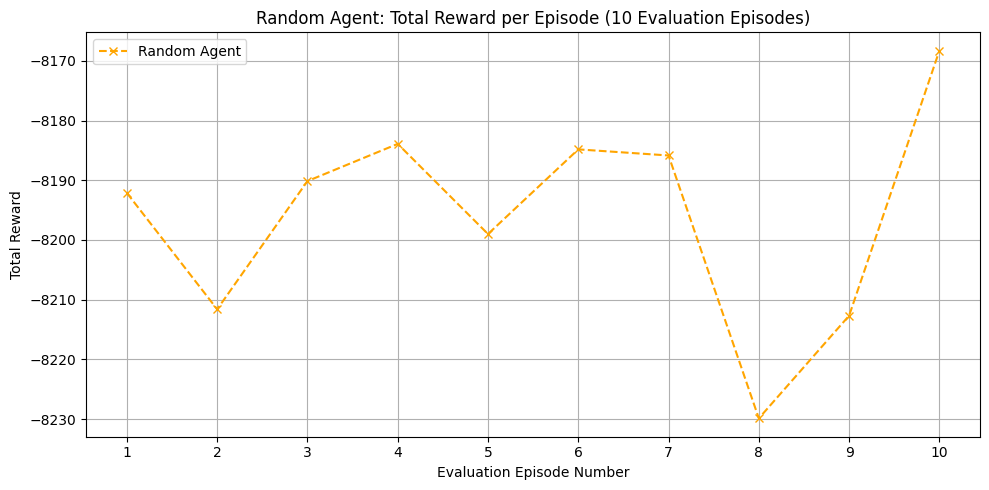


Plotting Comparison: PPO vs Random Agent Rewards


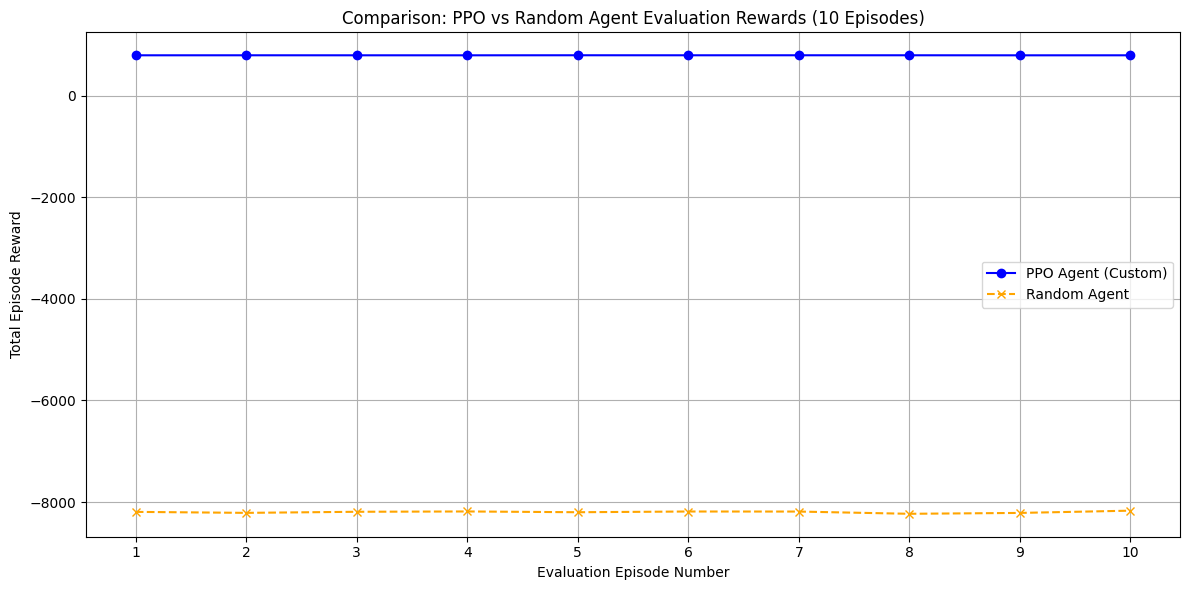


Random Agent Evaluation and Comparison Script Finished


In [ ]:
print("\nEvaluating and Visualizing Random Agent")

N_EPISODES_RANDOM = 10
N_STEPS_PER_EPISODE_RANDOM = N_STEPS_PER_EPISODE
PAUSE_DURATION_RANDOM = PAUSE_DURATION

required_vars = ['env_kwargs', 'RESOURCE_TYPES', 'grid_gdf', 'lat_edges', 'lon_edges', 'all_episode_rewards_vis', 'N_STEPS_PER_EPISODE', 'PAUSE_DURATION']
missing_vars = []
for var_name in required_vars:
    if var_name not in locals() and var_name not in globals():
        missing_vars.append(var_name)

if missing_vars:
    print(f"ERROR: Required variables from the main PPO script run are not found: {missing_vars}")
    CAN_RUN_RANDOM_EVAL = False
else:
    print("Prerequisite variables found. Proceeding with Random Agent evaluation.")
    CAN_RUN_RANDOM_EVAL = True

if CAN_RUN_RANDOM_EVAL:
    try:
        eval_env_random = ResourceAllocationEnv(**env_kwargs)
        print("Created evaluation environment instance for Random Agent.")
    except Exception as e:
        print(f"ERROR: Could not create evaluation environment for Random Agent. Details: {e}")
        eval_env_random = None

    if eval_env_random:
        all_episode_rewards_random = []
        fig_rand, ax_rand = plt.subplots(figsize=(15, 15))
        print(f"\nStarting Random Agent visualization for {N_EPISODES_RANDOM} episodes...")

        for episode in range(N_EPISODES_RANDOM):
            print(f"\nStarting Random Agent Visualization Episode {episode + 1}/{N_EPISODES_RANDOM}")
            obs_rand, info_rand = eval_env_random.reset()
            episode_reward_random = 0
            env_grid_ids_rand = eval_env_random.grid_ids

            for step in range(N_STEPS_PER_EPISODE_RANDOM):
                random_action = eval_env_random.action_space.sample()
                obs_rand, reward_rand, terminated_rand, truncated_rand, info_rand = eval_env_random.step(random_action)
                episode_reward_random += reward_rand
                current_allocation_np_rand = eval_env_random.current_allocation

                if len(env_grid_ids_rand) == current_allocation_np_rand.shape[0]:
                    alloc_df_rand = pd.DataFrame(current_allocation_np_rand, index=env_grid_ids_rand,
                                             columns=[f"{res}_alloc" for res in RESOURCE_TYPES]).reset_index().rename(columns={'index': 'grid_id'})
                    plot_data_gdf_rand = grid_gdf.merge(alloc_df_rand, on='grid_id', how='left').fillna(0)
                else:
                    print(f"Warning (Random Ep {episode+1}, Step {step+1}): Mismatch between env grid IDs ({len(env_grid_ids_rand)}) and allocation shape ({current_allocation_np_rand.shape[0]}). Skipping allocation merge for plotting.")
                    plot_data_gdf_rand = grid_gdf.copy()

                ax_rand.clear()
                plot_data_gdf_rand.plot(ax=ax_rand, facecolor='none', edgecolor='grey', linewidth=0.5, alpha=0.7)

                for idx, row in plot_data_gdf_rand.iterrows():
                    p_alloc = int(row.get(f'police_alloc', 0))
                    e_alloc = int(row.get(f'ems_alloc', 0))
                    f_alloc = int(row.get(f'fire_alloc', 0))
                    d_alloc = int(row.get(f'dot_alloc', 0))
                    total_alloc_cell = p_alloc + e_alloc + f_alloc + d_alloc

                    if total_alloc_cell > 0:
                        alloc_text = f"P:{p_alloc} E:{e_alloc}\nF:{f_alloc} D:{d_alloc}"
                        try:
                            if row.geometry and row.geometry.is_valid:
                                centroid = row.geometry.centroid
                                ax_rand.text(centroid.x, centroid.y, alloc_text, ha='center', va='center', fontsize=6, color='black',
                                        bbox=dict(boxstyle='round,pad=0.1', fc='yellow', alpha=0.6, ec='none'))
                        except AttributeError:
                             print(f"Warning: Could not get centroid for geometry at index {idx}. Skipping text.")

                try:
                    ctx.add_basemap(ax_rand, source=ctx.providers.CartoDB.Positron)
                except Exception as e_ctx:
                    print(f"Warning: Could not add basemap during random agent visualization. {e_ctx}")

                ax_rand.set_title(f"RANDOM Agent - Evaluation Episode {episode + 1}, Step {step + 1}/{N_STEPS_PER_EPISODE_RANDOM}\n"
                                 f"Current Step Reward: {reward_rand:.2f} | Episode Total Reward: {episode_reward_random:.2f}", fontsize=10)
                ax_rand.axis('off')

                display.display(fig_rand)
                display.clear_output(wait=True)
                time.sleep(PAUSE_DURATION_RANDOM)

                if terminated_rand or truncated_rand:
                    print(f"Random Agent Episode {episode + 1} finished early at step {step + 1} (Terminated: {terminated_rand}, Truncated: {truncated_rand}).")
                    break

            print(f"Random Agent Visualization Episode {episode + 1} Finished. Final Total Reward: {episode_reward_random:.2f}")
            all_episode_rewards_random.append(episode_reward_random)
            time.sleep(0.5)

        plt.close(fig_rand)
        print("\nRandom Agent Map Visualization finished.")
        eval_env_random.close()
        print("Random Agent evaluation environment closed.")

        if all_episode_rewards_random:
            plt.figure(figsize=(10, 5))
            episode_numbers_rand = range(1, len(all_episode_rewards_random) + 1)
            plt.plot(episode_numbers_rand, all_episode_rewards_random, marker='x', linestyle='--', color='orange', label='Random Agent')
            plt.title(f'Random Agent: Total Reward per Episode ({len(all_episode_rewards_random)} Evaluation Episodes)')
            plt.xlabel('Evaluation Episode Number')
            plt.ylabel('Total Reward')
            if len(episode_numbers_rand) <= 20 :
                 plt.xticks(episode_numbers_rand)
            else:
                 plt.locator_params(axis='x', nbins=10)
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("No episode rewards recorded during random agent evaluation visualization.")

        print("\nPlotting Comparison: PPO vs Random Agent Rewards")

        ppo_rewards_exist = 'all_episode_rewards_vis' in locals() or 'all_episode_rewards_vis' in globals()
        random_rewards_exist = 'all_episode_rewards_random' in locals() or 'all_episode_rewards_random' in globals()

        if ppo_rewards_exist and random_rewards_exist and len(all_episode_rewards_vis) == N_EPISODES_RANDOM and len(all_episode_rewards_random) == N_EPISODES_RANDOM:
            plt.figure(figsize=(12, 6))
            episode_numbers_comp = range(1, N_EPISODES_RANDOM + 1)
            plt.plot(episode_numbers_comp, all_episode_rewards_vis, marker='o', linestyle='-', color='blue', label=f'PPO Agent (Custom)')
            plt.plot(episode_numbers_comp, all_episode_rewards_random, marker='x', linestyle='--', color='orange', label='Random Agent')
            plt.title(f'Comparison: PPO vs Random Agent Evaluation Rewards ({N_EPISODES_RANDOM} Episodes)')
            plt.xlabel('Evaluation Episode Number')
            plt.ylabel('Total Episode Reward')
            if N_EPISODES_RANDOM <= 20 :
                 plt.xticks(episode_numbers_comp)
            else:
                 plt.locator_params(axis='x', nbins=10)
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        else:
            print("Could not generate comparison plot. Check the following:")
            if not ppo_rewards_exist:
                print("- PPO evaluation rewards ('all_episode_rewards_vis') were not found. Ensure Section 5 ran successfully.")
            elif len(all_episode_rewards_vis) != N_EPISODES_RANDOM:
                print(f"- PPO rewards list length ({len(all_episode_rewards_vis)}) doesn't match expected ({N_EPISODES_RANDOM}).")
            if not random_rewards_exist:
                print("- Random agent evaluation rewards ('all_episode_rewards_random') were not found. Ensure Random Agent evaluation ran.")
            elif len(all_episode_rewards_random) != N_EPISODES_RANDOM:
                 print(f"- Random agent rewards list length ({len(all_episode_rewards_random)}) doesn't match expected ({N_EPISODES_RANDOM}).")
    else:
        print("Skipping Random Agent evaluation and comparison due to environment creation failure.")
else:
    print("Skipping Random Agent evaluation and comparison because prerequisite variables were missing.")

print("\nRandom Agent Evaluation and Comparison Script Finished")
